# Latent Space Perturbation Demo

This notebook demonstrates key concepts from:

"Latent Space Perturbation Reveals Approximate Additive Gene Effects in Single-Cell Transcriptomic Dynamics"

In [11]:
!pip install scanpy torch numpy matplotlib

In [12]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Load dataset
adata = sc.datasets.pbmc68k_reduced()

# --- Step 1: Remove bad cells ---
sc.pp.filter_cells(adata, min_counts=1)

# --- Step 2: Remove genes with no signal ---
sc.pp.filter_genes(adata, min_counts=1)

# --- Step 3: Normalize + log ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- Step 4: Remove NaNs / infs (critical fix) ---
adata.X = np.nan_to_num(adata.X)

# --- Step 5: Highly variable genes (robust method) ---
sc.pp.highly_variable_genes(
adata,
flavor="cell_ranger", # ← more stable than seurat here
n_top_genes=2000
)

# --- Step 6: Subset ---
adata = adata[:, adata.var.highly_variable]

/tmp/ipykernel_4271/3445121616.py:11: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:377: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


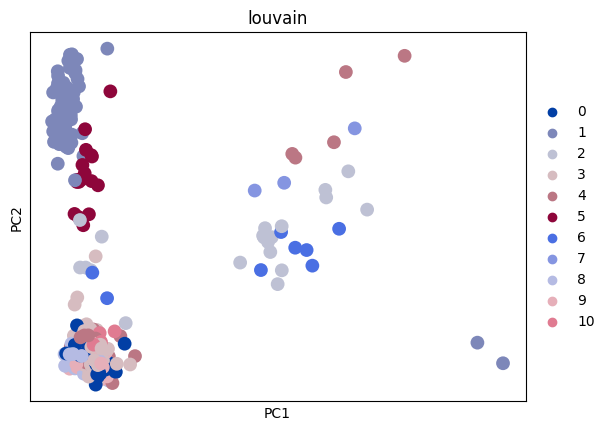

In [14]:
sc.tl.pca(adata)
sc.pl.pca(adata, color='louvain')

In [15]:
gene = adata.var_names[0]
adata_perturbed = adata.copy()
adata_perturbed[:, gene].X *= 0.5

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:639: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_4271/1869593076.py:3: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:, gene].X *= 0.5


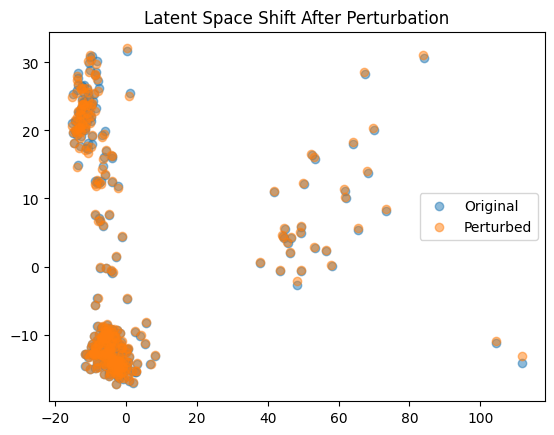

In [16]:
sc.tl.pca(adata_perturbed)

plt.scatter(
adata.obsm['X_pca'][:,0],
adata.obsm['X_pca'][:,1],
alpha=0.5,
label='Original'
)

plt.scatter(
adata_perturbed.obsm['X_pca'][:,0],
adata_perturbed.obsm['X_pca'][:,1],
alpha=0.5,
label='Perturbed'
)

plt.legend()
plt.title("Latent Space Shift After Perturbation")
plt.show()



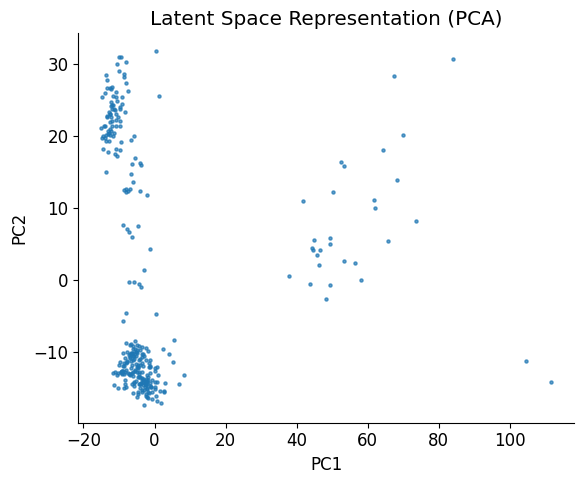

In [17]:
import matplotlib.pyplot as plt

plt.rcParams.update({
"figure.figsize": (6,5),
"font.size": 12,
"axes.spines.top": False,
"axes.spines.right": False
})

X = adata.obsm['X_pca']

plt.figure()
plt.scatter(X[:,0], X[:,1], s=5, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Space Representation (PCA)")

plt.tight_layout()
plt.savefig("figure1_latent_space.png", dpi=300)

plt.show()


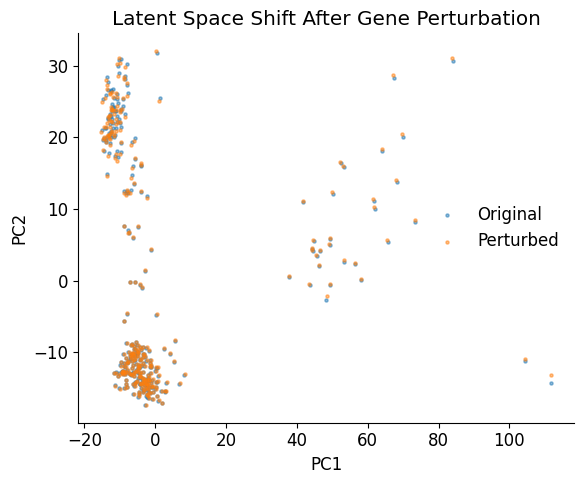

In [18]:
X_orig = adata.obsm['X_pca']
X_pert = adata_perturbed.obsm['X_pca']

plt.figure(figsize=(6,5))

plt.scatter(X_orig[:,0], X_orig[:,1], s=5, alpha=0.5, label="Original")
plt.scatter(X_pert[:,0], X_pert[:,1], s=5, alpha=0.5, label="Perturbed")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Space Shift After Gene Perturbation")

plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("figure2_perturbation.png", dpi=300)

plt.show()

In [19]:
import numpy as np

shift = X_pert - X_orig
magnitude = np.linalg.norm(shift, axis=1)

print("Mean shift magnitude:", magnitude.mean())
print("Std shift magnitude:", magnitude.std())


Mean shift magnitude: 10.486141
Std shift magnitude: 4.5642695


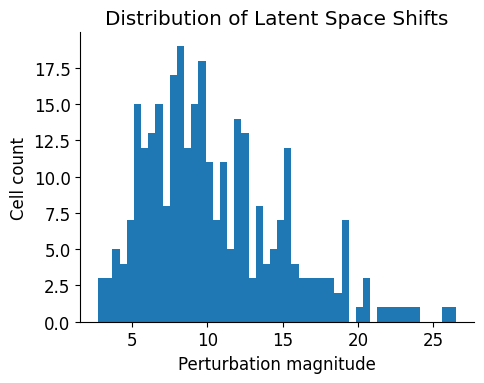

In [20]:
plt.figure(figsize=(5,4))

plt.hist(magnitude, bins=50)

plt.xlabel("Perturbation magnitude")
plt.ylabel("Cell count")
plt.title("Distribution of Latent Space Shifts")

plt.tight_layout()
plt.savefig("figure3_shift_distribution.png", dpi=300)

plt.show()